In [1]:
from typing import Optional, Dict

import numpy as np
import matplotlib.pyplot as plt

import itertools

from pathlib import Path

from data import DynamicsDatasetMode

In [2]:
NONEMBED_BASE_DATA_DIR = Path("./nonembed_results")
SUBDIR_PATH = "dim_{dim}/radius_{radius}"

In [21]:
RADII = [0.5, 1.0, 2.0]
DIMS = [1, 2, 3, 4]
MODES = [
    "Single",
    "Multiple",
    "Multiple (w/ Validity)",
    "Ambient"
]
CONFIGS = [
    {"num_hidden_layers": 5, "num_nodes": 60, "label": "Cfg 1"},
    {"num_hidden_layers": 6, "num_nodes": 60, "label": "Cfg 2"},
    {"num_hidden_layers": 7, "num_nodes": 60, "label": "Cfg 3"}
]


def get_cfg(num_hidden_layers: int, num_nodes: int) -> int:
    for i in range(len(CONFIGS)):
        cfg = CONFIGS[i]
        if cfg["num_hidden_layers"] == num_hidden_layers and cfg["num_nodes"] == num_nodes:
            return i

    raise ValueError("configuration not found")


def get_cfg_label(num_hidden_layers: int, num_nodes: int) -> str:
    cfg = get_cfg(num_hidden_layers, num_nodes)
    return CONFIGS[cfg]["label"]

In [4]:
training_paths = []
for radius, dim in itertools.product(RADII, DIMS):
    data_dir = NONEMBED_BASE_DATA_DIR / str.format(SUBDIR_PATH, radius=radius, dim=dim)
    for child in data_dir.iterdir():
        if child.is_file() and child.name.endswith(".npz"):
            training_paths.append(child)

numpy_training_data = [
    np.load(path, allow_pickle=True) for path in training_paths
]

In [5]:
# process the training data into a more convenient format
training_data = []
for numpy_loaded in numpy_training_data:
    run = {
        "n": numpy_loaded["n"],
        "radius": numpy_loaded["radius"],
        "num_hidden_layers": numpy_loaded["num_hidden_layers"],
        "num_nodes_in_hidden_layer": numpy_loaded["num_nodes_in_hidden_layer"],
        "batch_size": numpy_loaded["batch_size"],
        "mode": numpy_loaded["mode"].item(),  # gets the enum from the object array
        "lr": numpy_loaded["lr"],
        "train_batch_loss_hist": numpy_loaded["train_batch_loss_hist_numpy"],
        "valid_batch_loss_hist": numpy_loaded["valid_batch_loss_hist_numpy"],
    }

    # computes the statistics on the runs
    train_max_batch_loss_hist = np.max(run["train_batch_loss_hist"], axis=1)
    train_min_batch_loss_hist = np.min(run["train_batch_loss_hist"], axis=1)
    train_mean_batch_loss_hist = np.mean(run["train_batch_loss_hist"], axis=1)

    valid_max_batch_loss_hist = np.max(run["valid_batch_loss_hist"], axis=1)
    valid_min_batch_loss_hist = np.min(run["valid_batch_loss_hist"], axis=1)
    valid_mean_batch_loss_hist = np.mean(run["valid_batch_loss_hist"], axis=1)

    run.update({
        "train_max_batch_loss_hist": train_max_batch_loss_hist,
        "train_min_batch_loss_hist": train_min_batch_loss_hist,
        "train_mean_batch_loss_hist": train_mean_batch_loss_hist,
        "valid_max_batch_loss_hist": valid_max_batch_loss_hist,
        "valid_min_batch_loss_hist": valid_min_batch_loss_hist,
        "valid_mean_batch_loss_hist": valid_mean_batch_loss_hist,
    })

    training_data.append(run)

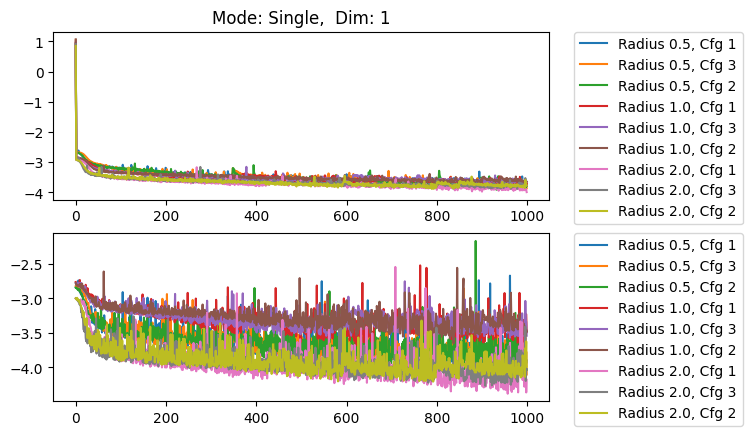

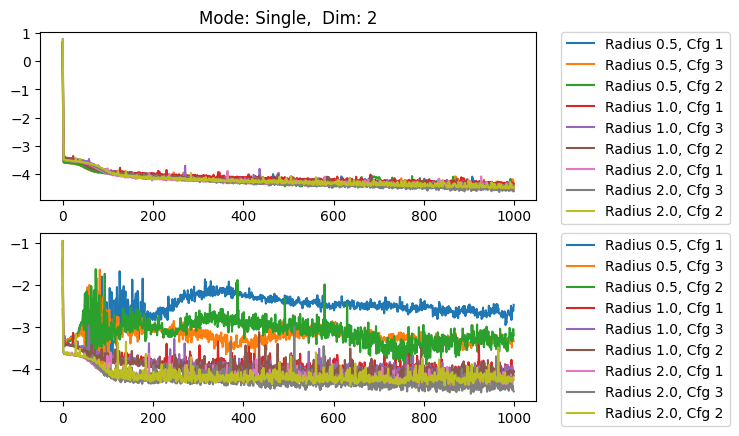

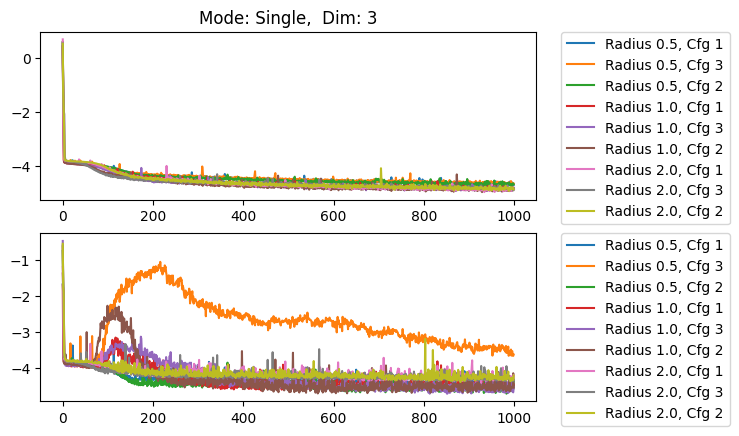

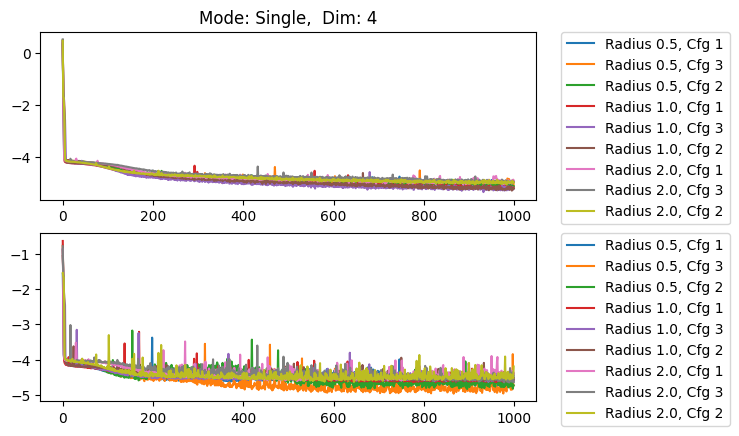

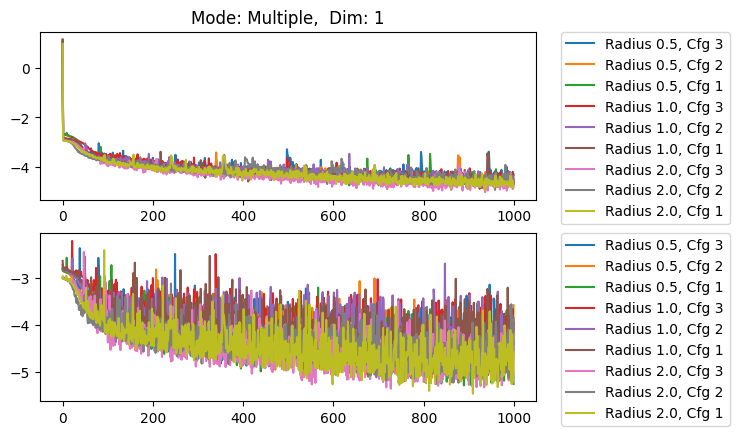

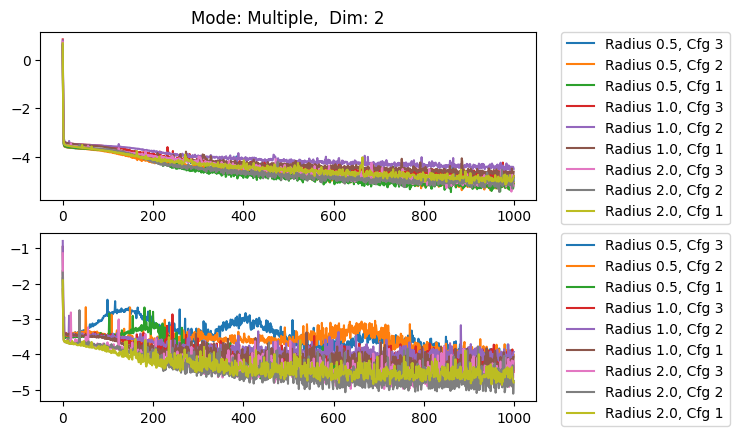

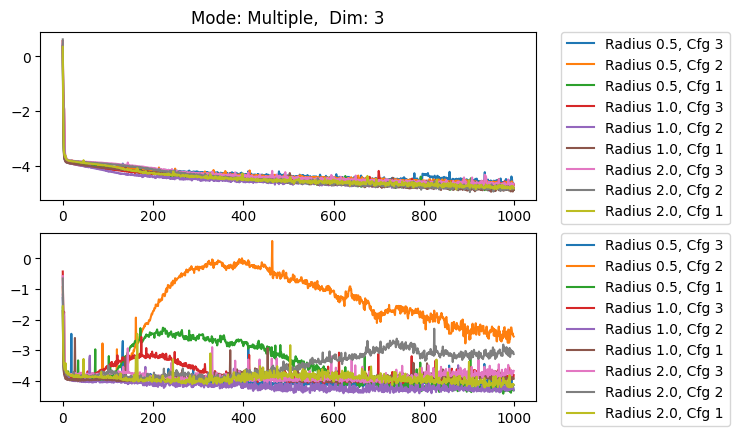

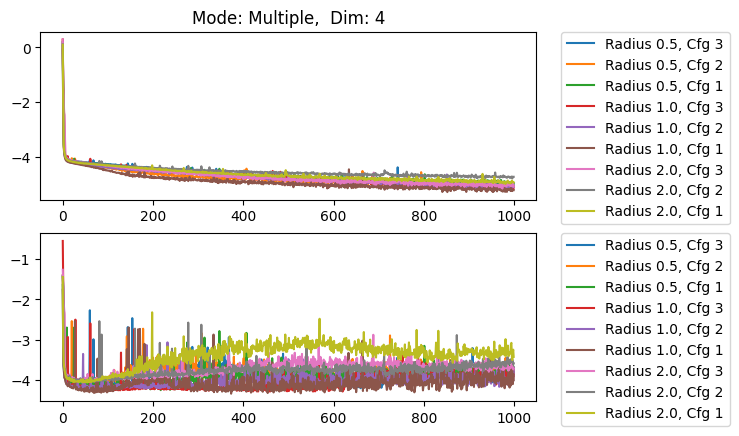

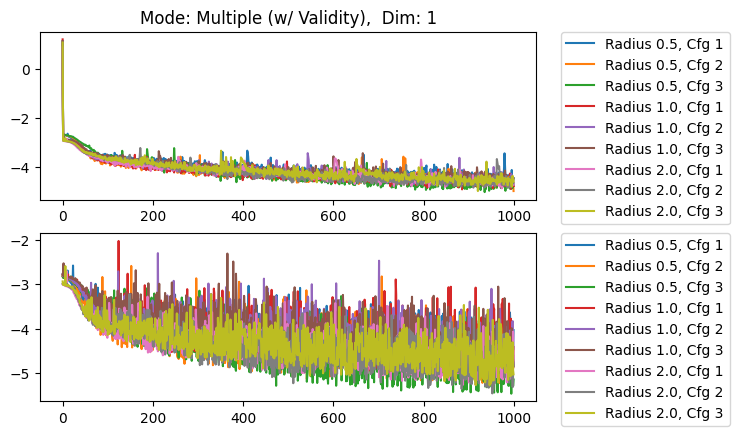

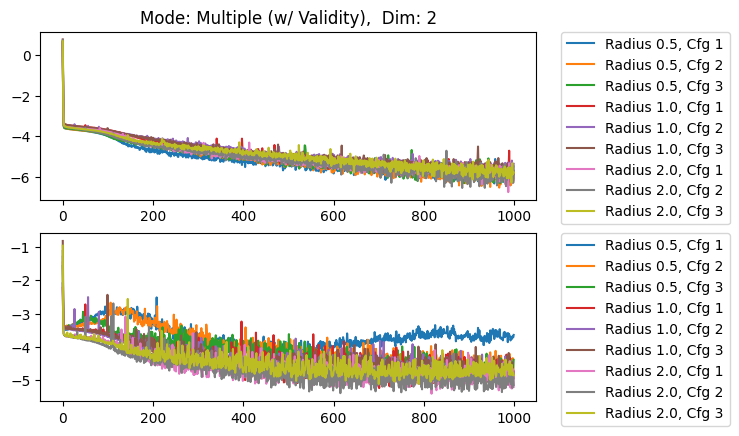

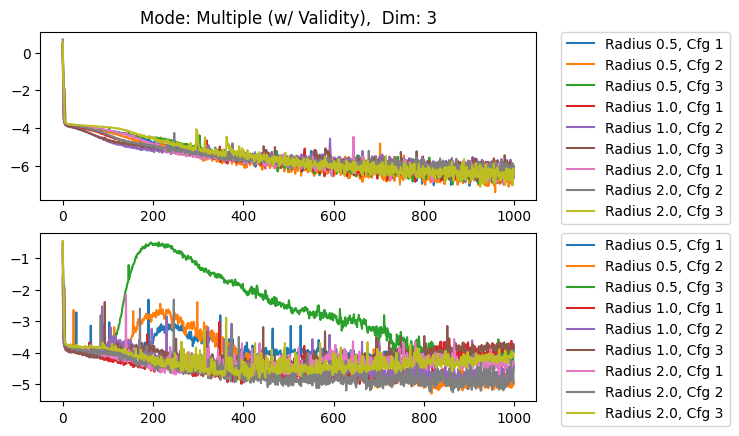

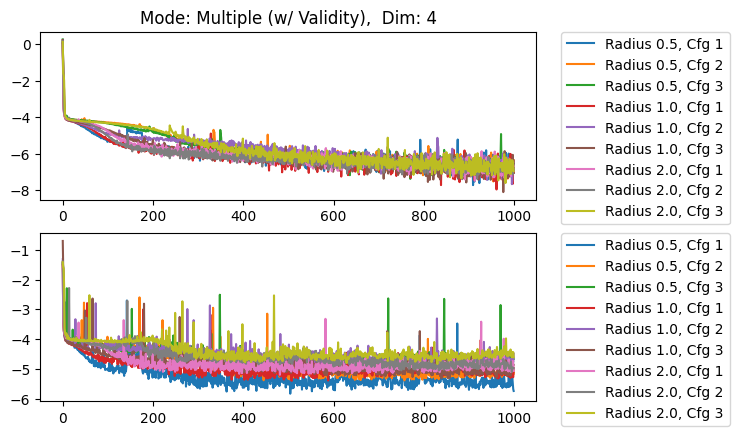

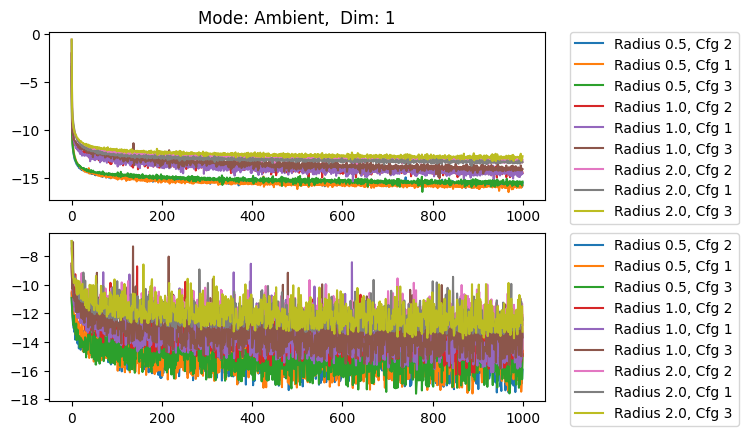

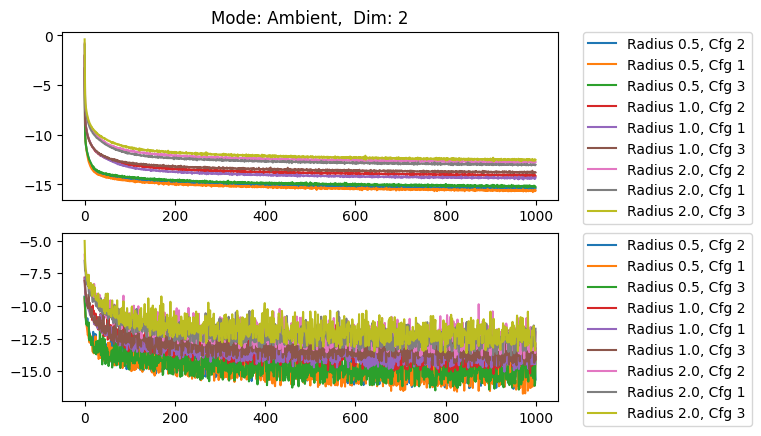

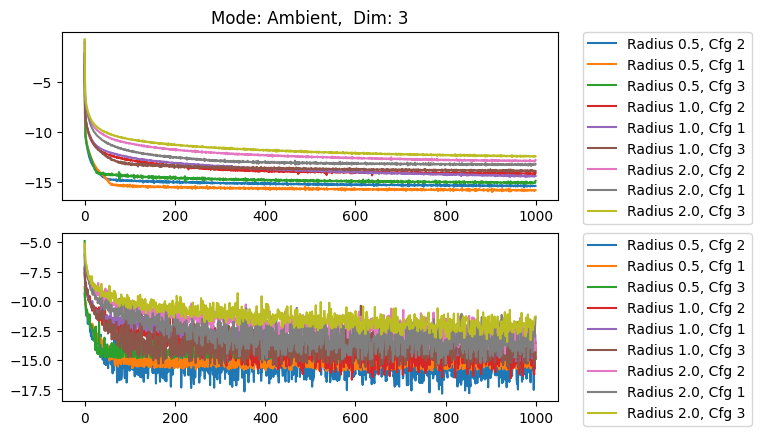

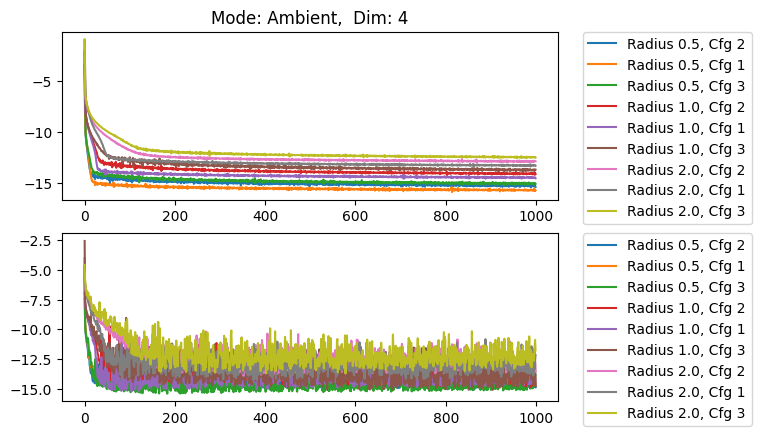

In [6]:
# plot the training/validation for each mode at each dimension
for mode, dim in itertools.product(MODES, DIMS):
    title = f"Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for data in training_data_for_mode:
        label = f"Radius {data["radius"]}, {get_cfg_label(data["num_hidden_layers"], data["num_nodes_in_hidden_layer"])}"

        train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=label)
        valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    pass

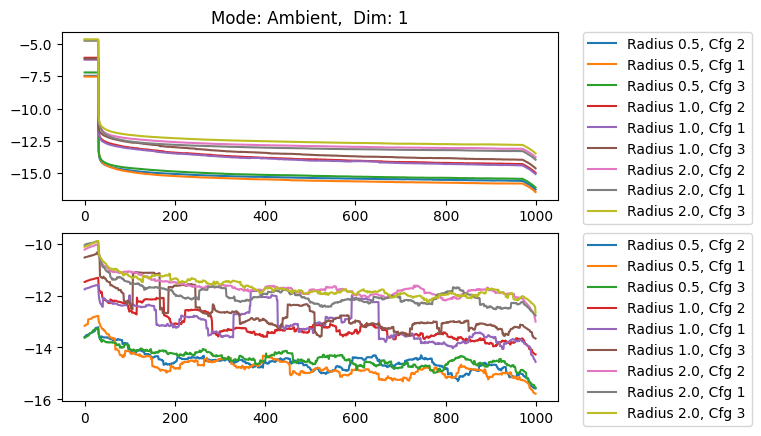

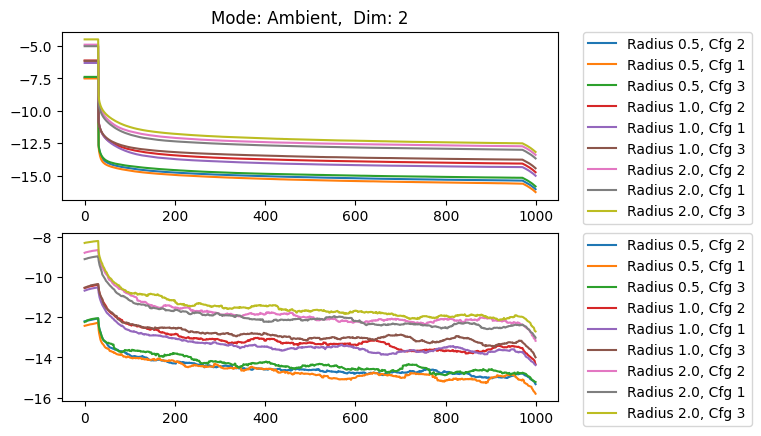

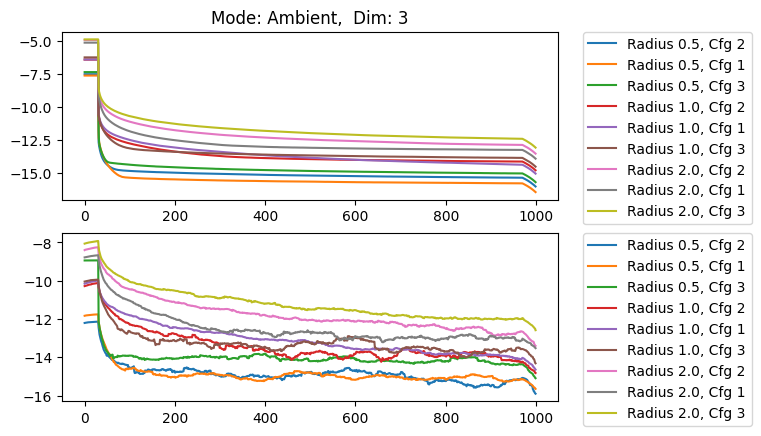

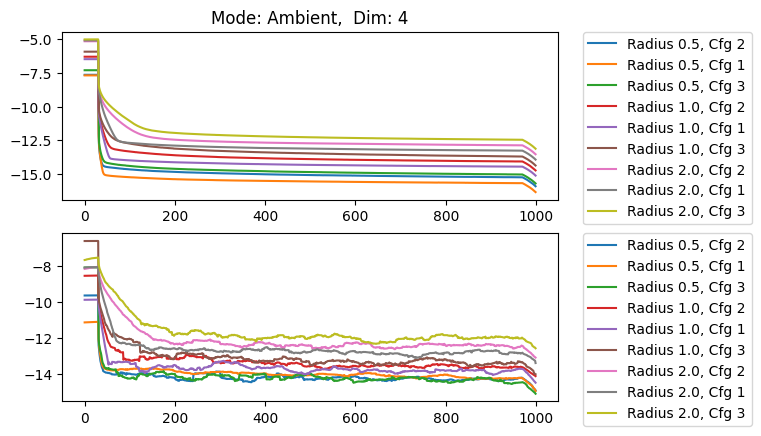

In [51]:
# to improve stability we want to  use a moving average on the ambient data to prevent the noise from the ambient training
# from showing up in the normalized results

window_size = 60
kernel = np.ones(window_size) / window_size

for dim in DIMS:
    mode = MODES[3]

    title = f"Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for data in training_data_for_mode:
        label = f"Radius {data["radius"]}, {get_cfg_label(data["num_hidden_layers"], data["num_nodes_in_hidden_layer"])}"

        train_ax.plot(np.log(np.convolve(data["train_mean_batch_loss_hist"], kernel, mode='same')), label=label)
        valid_ax.plot(np.log(np.convolve(data["valid_mean_batch_loss_hist"], kernel, mode='same')), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    pass

In [52]:
# due to having far too many configurations to analyze, we will normalize each training/validation run by the values
# obtained by the ambient training (best-case performance) which will allow us to compare relative performance between
# the various employed techniques

for data in training_data:
    extrinsic_data: Optional[Dict] = None
    if data["mode"].value == DynamicsDatasetMode.EXTRINSIC_COORD:
        extrinsic_data = data
    else:
        for other_data in training_data:
            # must find the extrinsic (ambient) version of data
            match_dim_and_radius = data["n"] == other_data["n"] and data["radius"] == other_data["radius"]
            match_cfg = data["num_hidden_layers"] == other_data["num_hidden_layers"] and \
                        data["num_nodes_in_hidden_layer"] == other_data["num_nodes_in_hidden_layer"]

            if match_dim_and_radius and match_cfg and other_data[
                "mode"].value == DynamicsDatasetMode.EXTRINSIC_COORD.value:
                extrinsic_data = other_data

    if extrinsic_data is None:
        raise ValueError("unable to find extrinsic data...")

    norm_train_max_batch_loss_hist = (data["train_max_batch_loss_hist"] /
                                      np.convolve(extrinsic_data["train_max_batch_loss_hist"], kernel, mode='same'))
    norm_train_min_batch_loss_hist = (data["train_min_batch_loss_hist"] /
                                      np.convolve(extrinsic_data["train_min_batch_loss_hist"], kernel, mode='same'))
    norm_train_mean_batch_loss_hist = (data["train_mean_batch_loss_hist"] /
                                       np.convolve(extrinsic_data["train_mean_batch_loss_hist"], kernel, mode='same'))

    norm_valid_max_batch_loss_hist = (data["valid_max_batch_loss_hist"] /
                                      np.convolve(extrinsic_data["valid_max_batch_loss_hist"], kernel, mode='same'))
    norm_valid_min_batch_loss_hist = (data["valid_min_batch_loss_hist"] /
                                      np.convolve(extrinsic_data["valid_min_batch_loss_hist"], kernel, mode='same'))
    norm_valid_mean_batch_loss_hist = (data["valid_mean_batch_loss_hist"] /
                                       np.convolve(extrinsic_data["valid_mean_batch_loss_hist"], kernel, mode='same'))

    # updates the data with the normalized values
    data.update({
        "norm_train_max_batch_loss_hist": norm_train_max_batch_loss_hist,
        "norm_train_min_batch_loss_hist": norm_train_min_batch_loss_hist,
        "norm_train_mean_batch_loss_hist": norm_train_mean_batch_loss_hist,
        "norm_valid_max_batch_loss_hist": norm_valid_max_batch_loss_hist,
        "norm_valid_min_batch_loss_hist": norm_valid_min_batch_loss_hist,
        "norm_valid_mean_batch_loss_hist": norm_valid_mean_batch_loss_hist,
    })


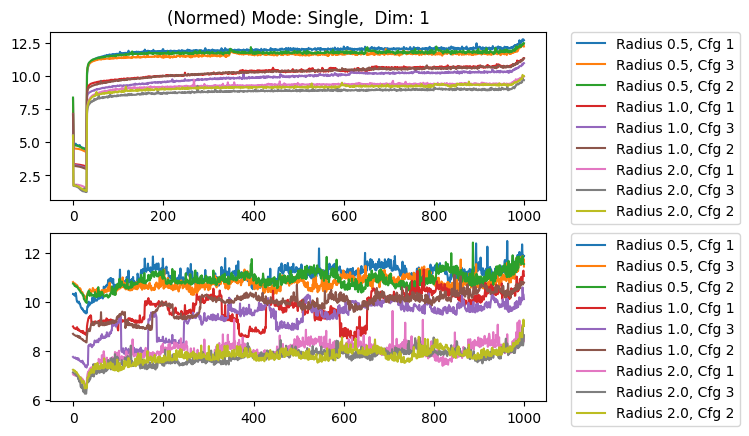

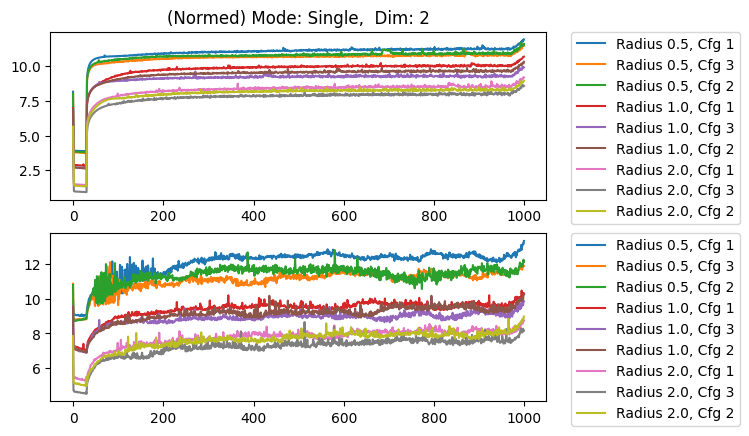

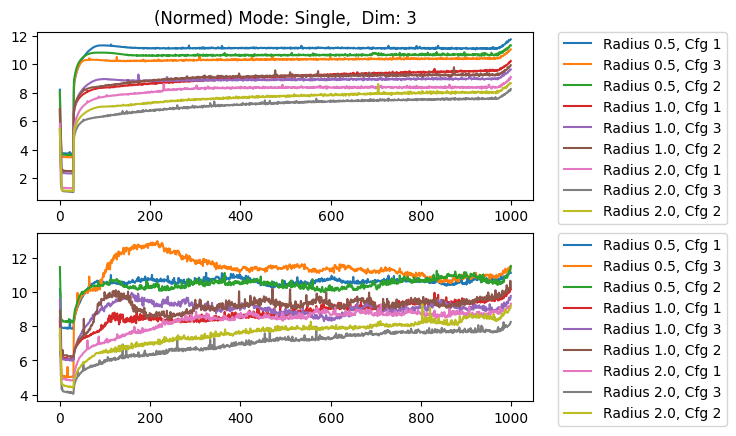

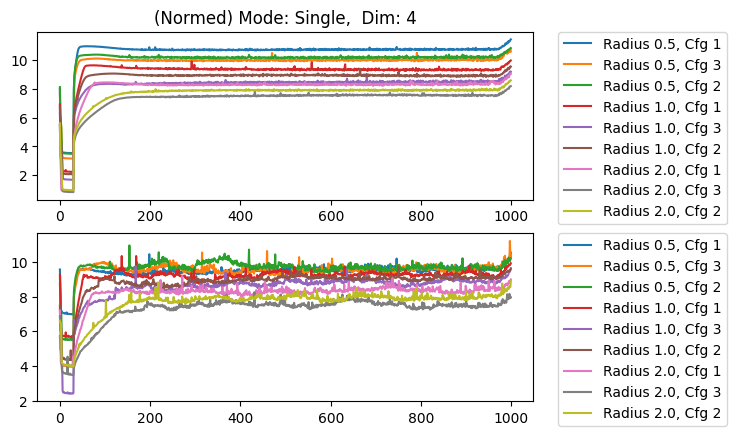

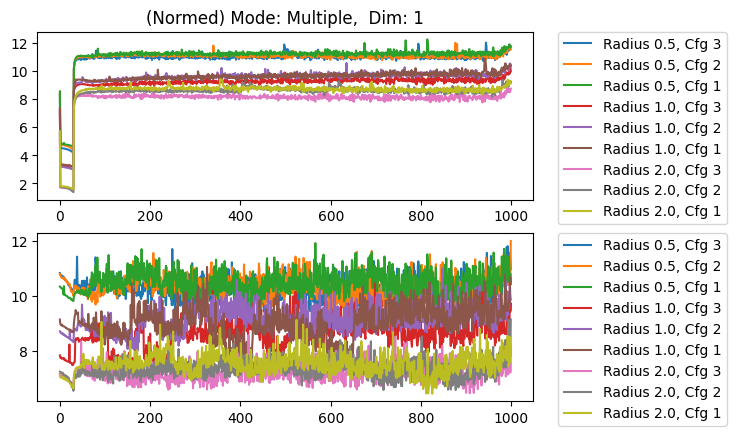

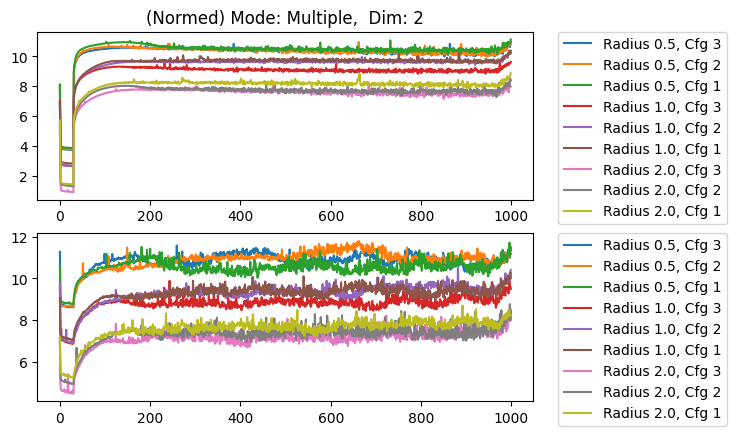

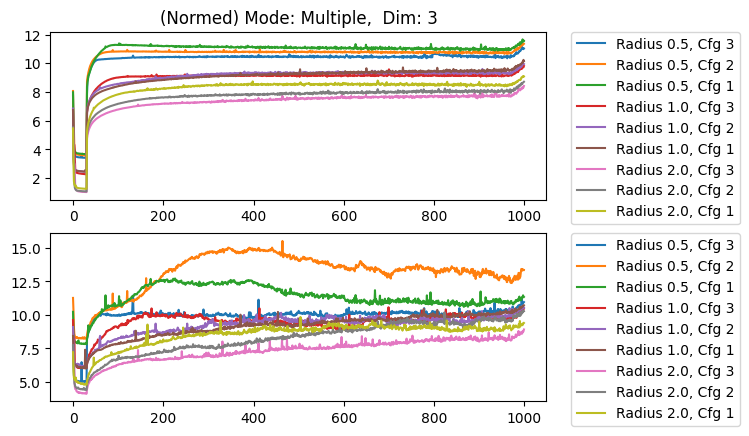

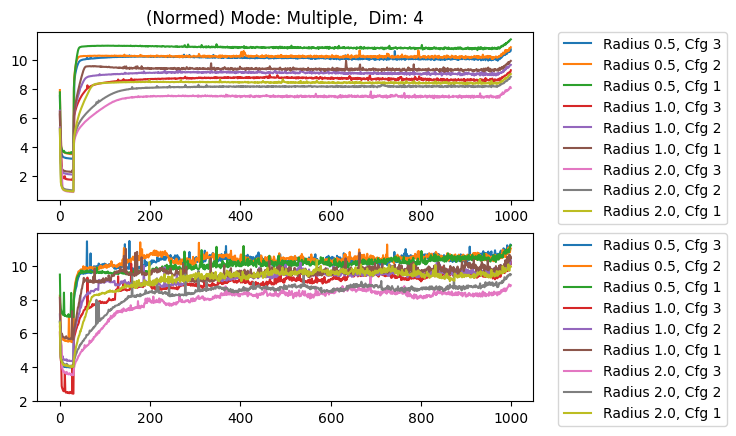

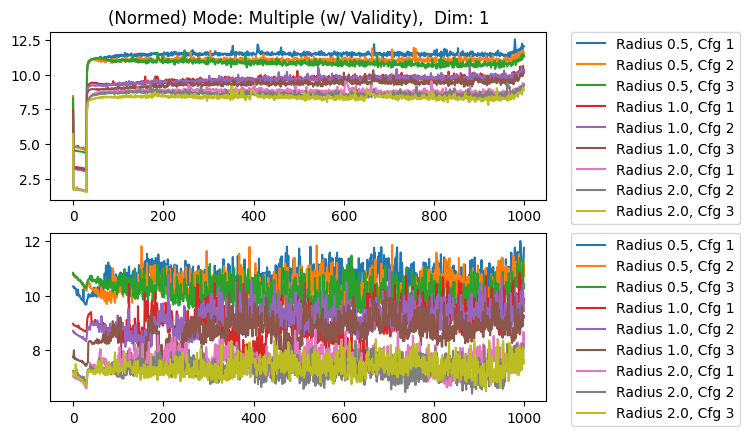

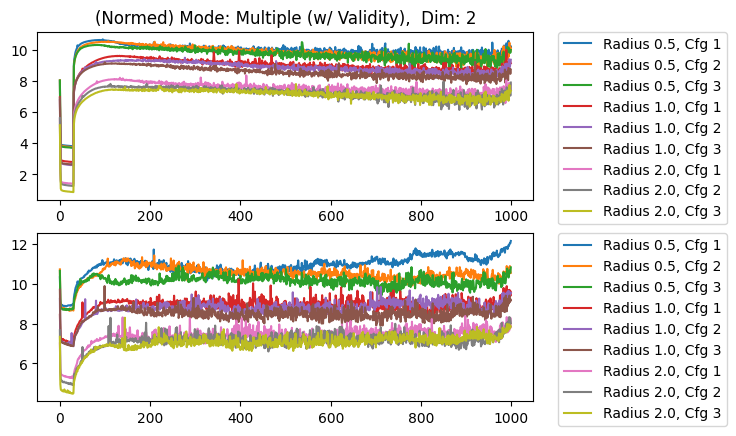

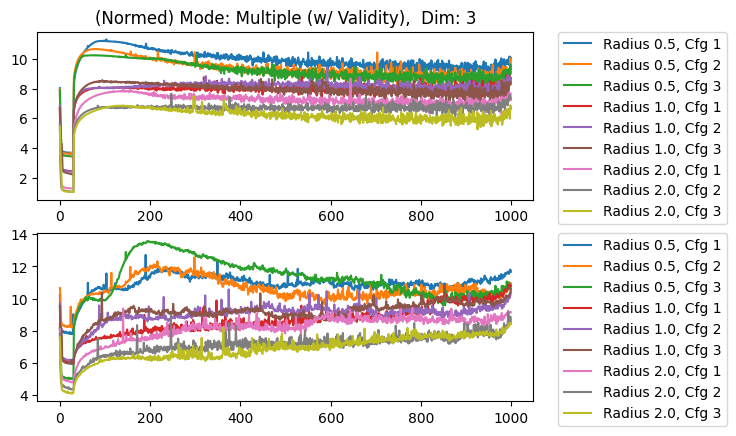

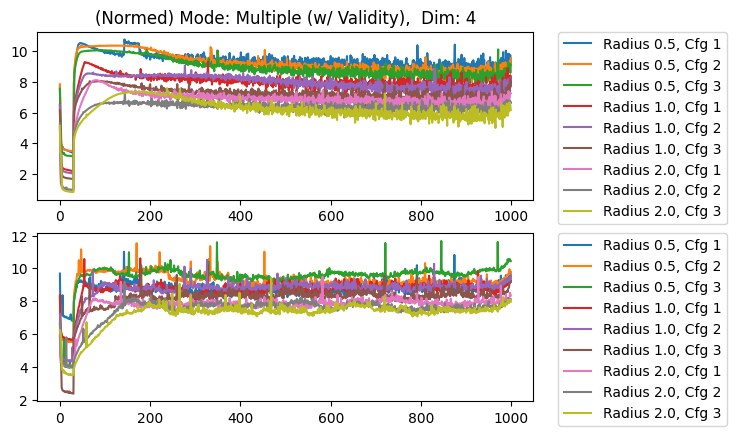

In [53]:
# plot the earlier plots but with the normalized results so we can view relative performance of each configuration
# NOTE: for the extrinsic (ambient) the values are identically 1 so we can just ignore it
for mode, dim in itertools.product(MODES[:-1], DIMS):
    title = f"(Normed) Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for data in training_data_for_mode:
        label = f"Radius {data["radius"]}, {get_cfg_label(data["num_hidden_layers"], data["num_nodes_in_hidden_layer"])}"

        train_ax.plot(np.log(data["norm_train_mean_batch_loss_hist"]), label=label)
        valid_ax.plot(np.log(data["norm_valid_mean_batch_loss_hist"]), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    pass

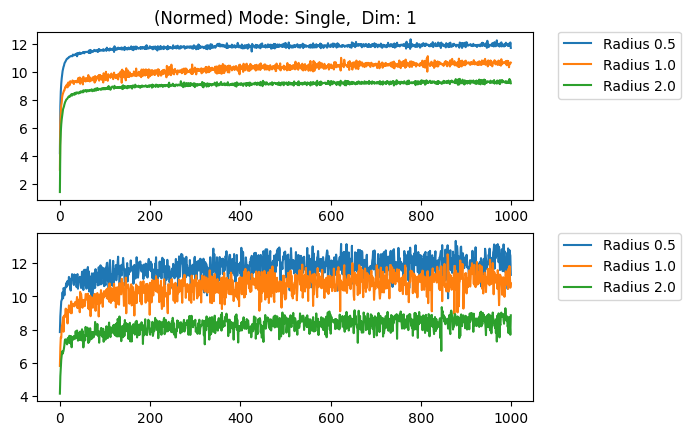

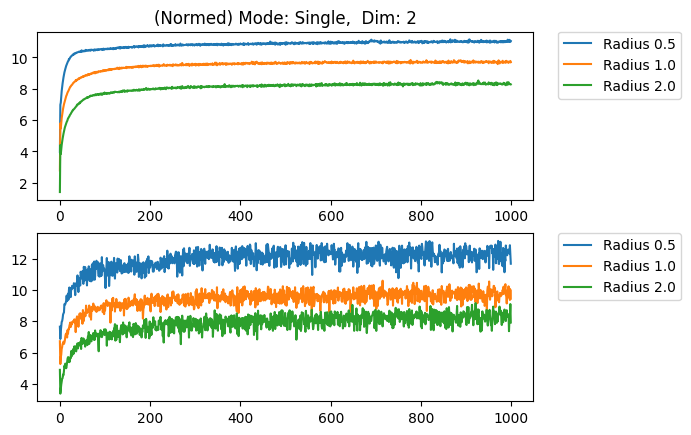

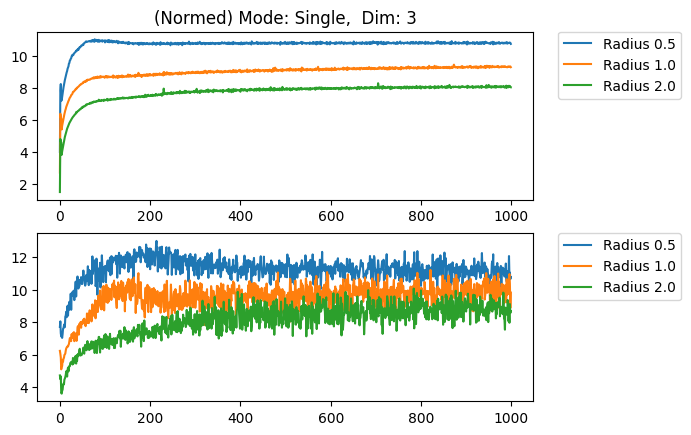

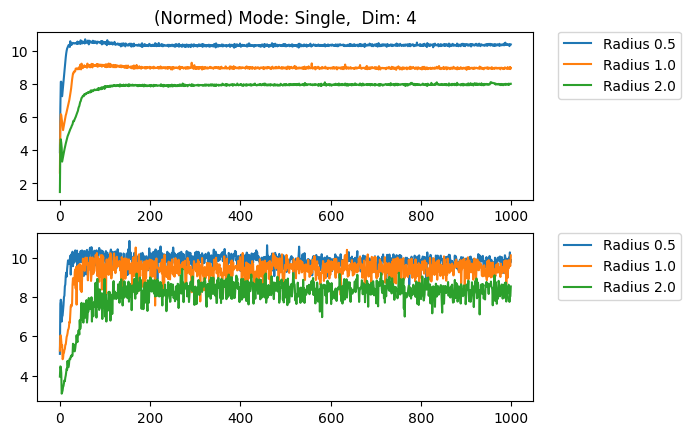

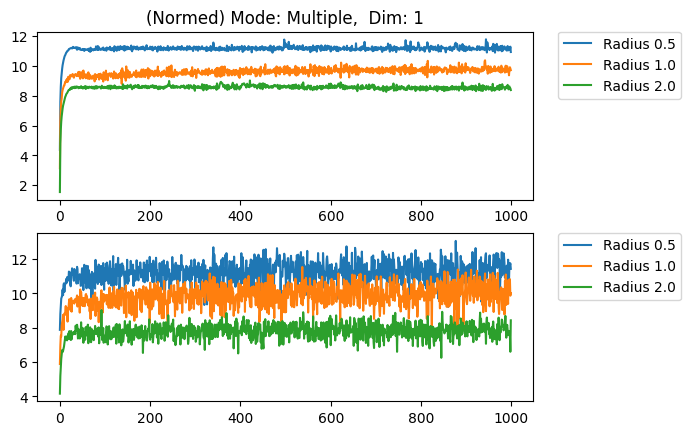

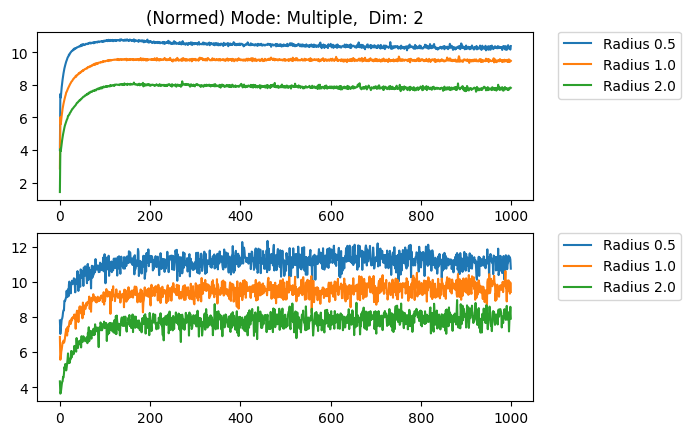

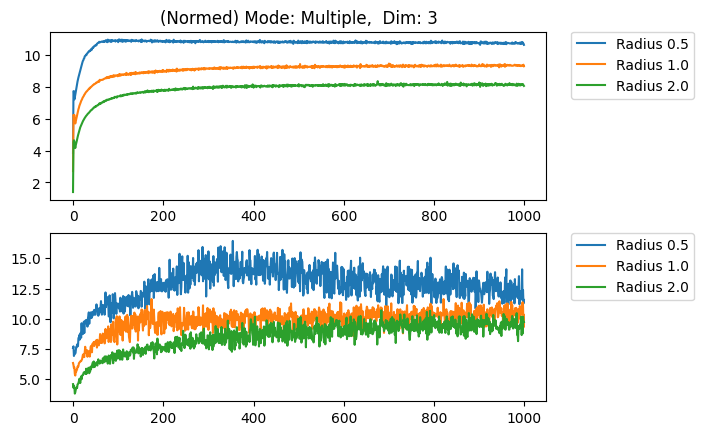

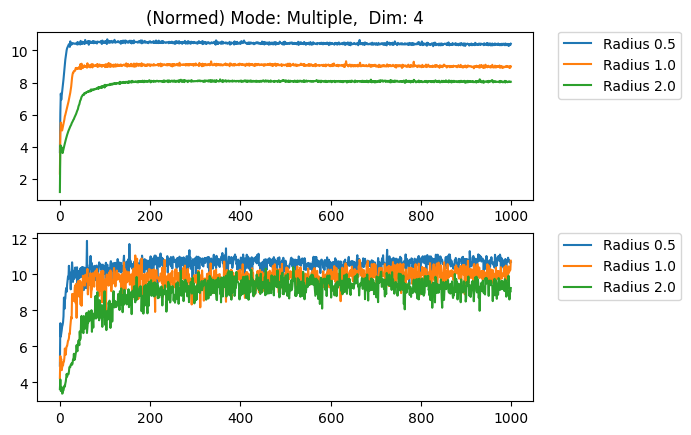

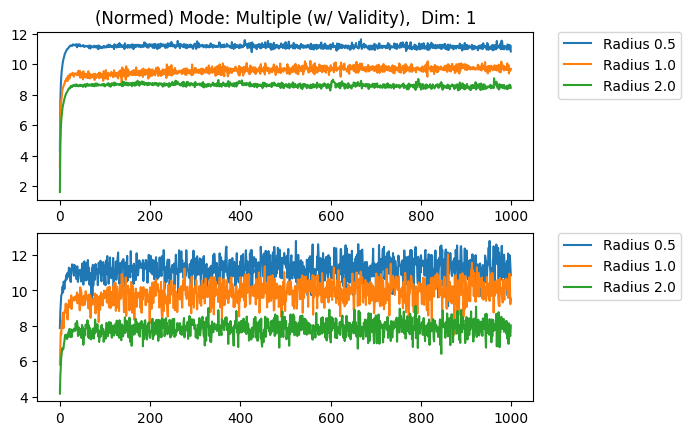

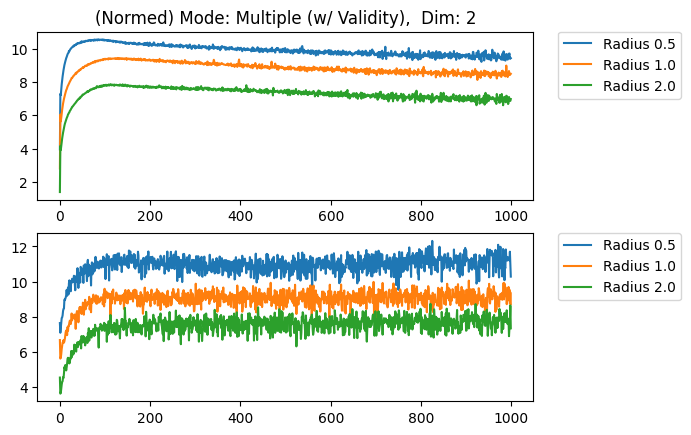

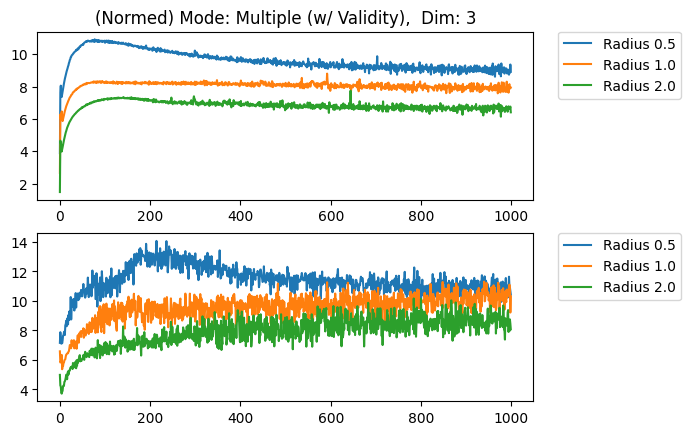

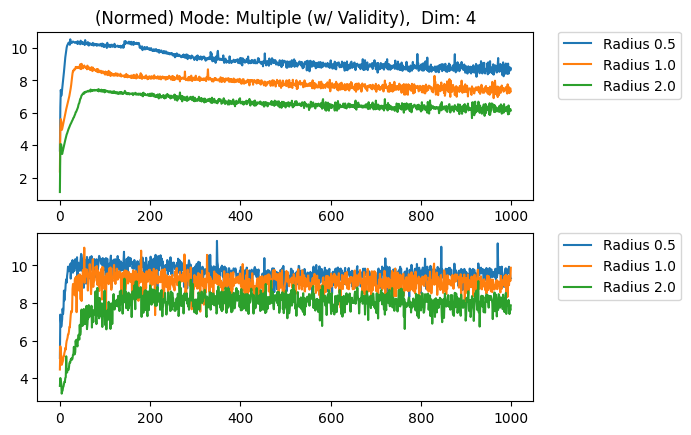

In [9]:
# present the same graphs with the normed values averaged across configurations
# NOTE: for the extrinsic (ambient) the values are identically 1 so we can just ignore it
for mode, dim in itertools.product(MODES[:-1], DIMS):
    title = f"(Normed) Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))
    cfg_data_for_radius = [
        list(filter(lambda data: data["radius"] == radius, training_data_for_mode)) for radius in RADII
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for radius, cfg_data in zip(RADII, cfg_data_for_radius):
        label = f"Radius {radius}"

        avg_cfg_train_loss = sum(data["norm_train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["norm_valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    pass

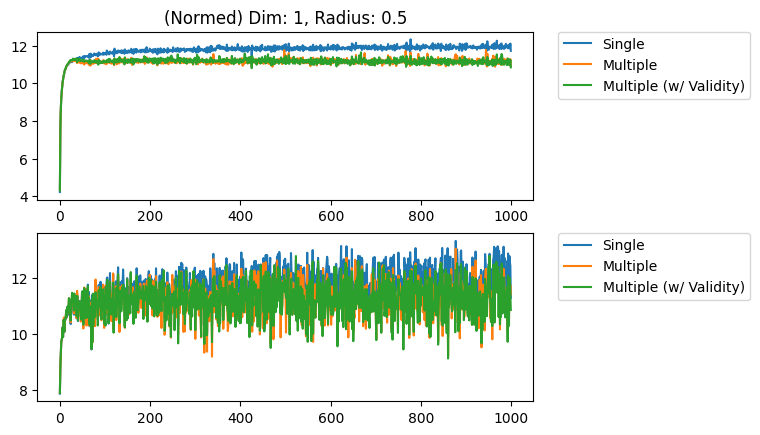

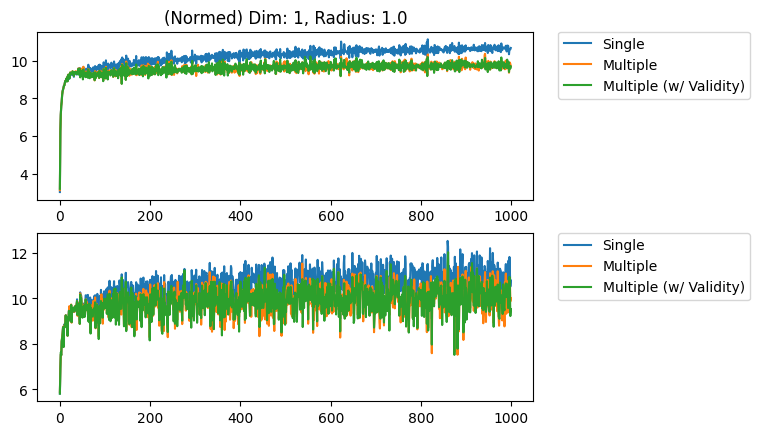

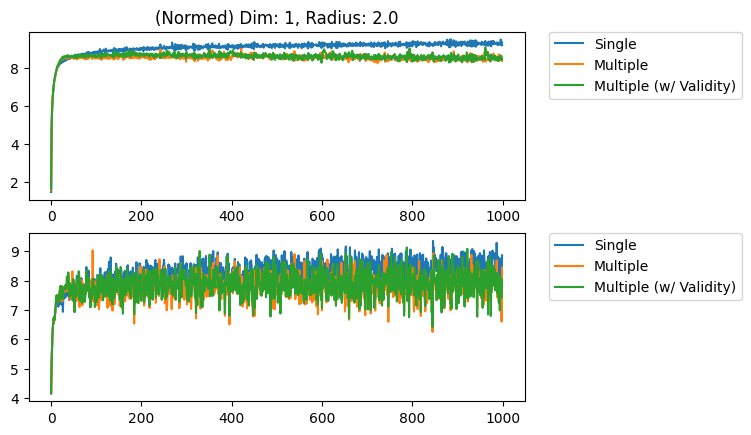

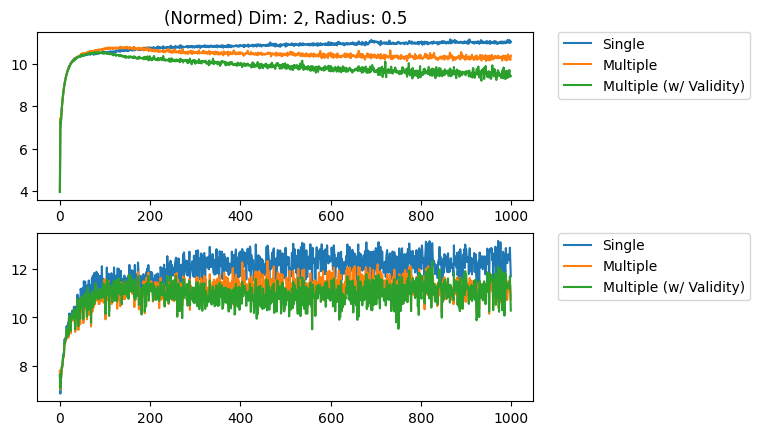

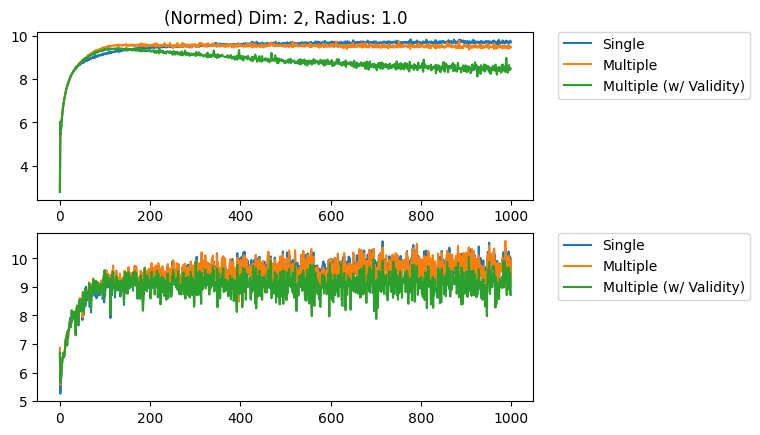

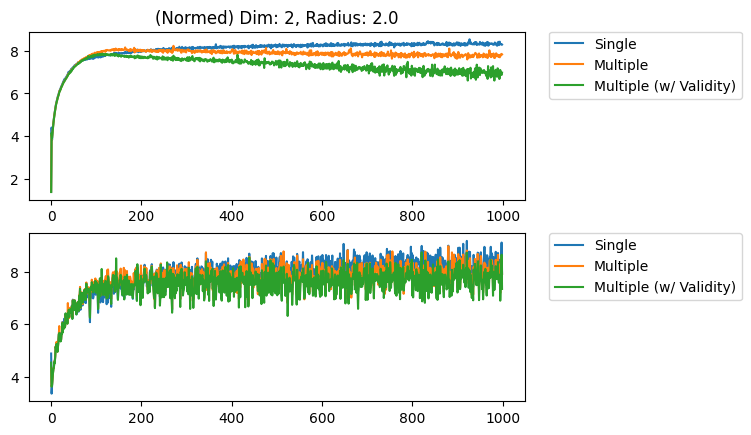

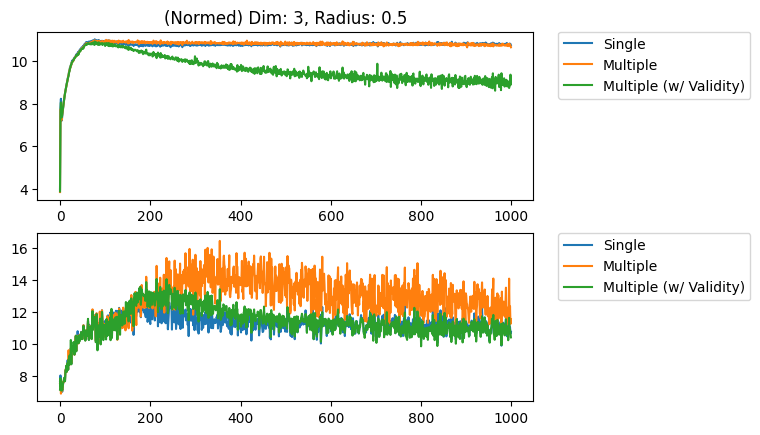

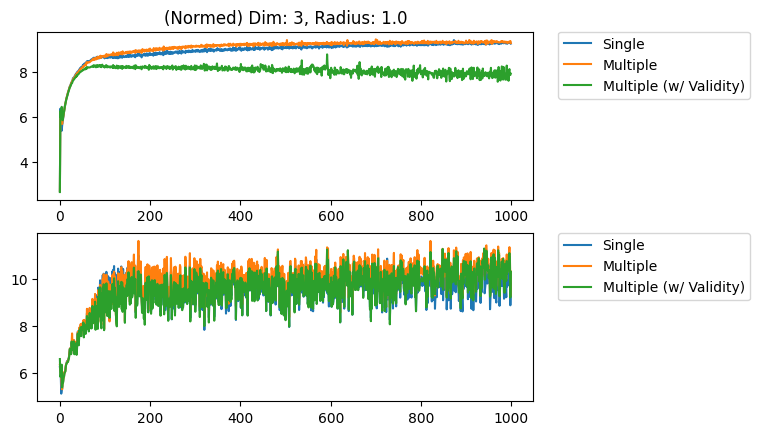

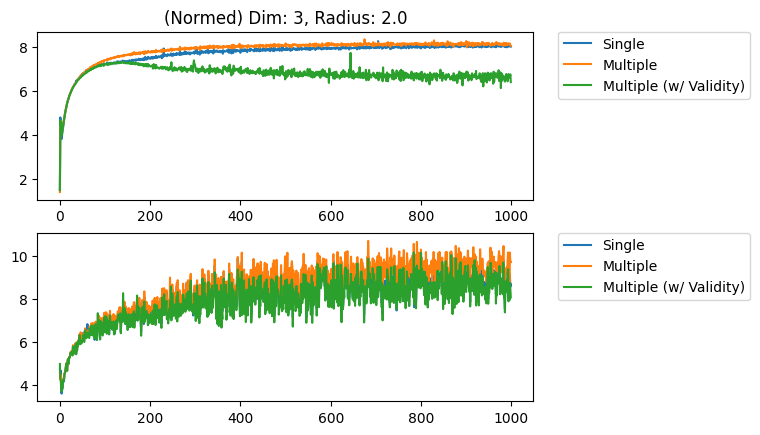

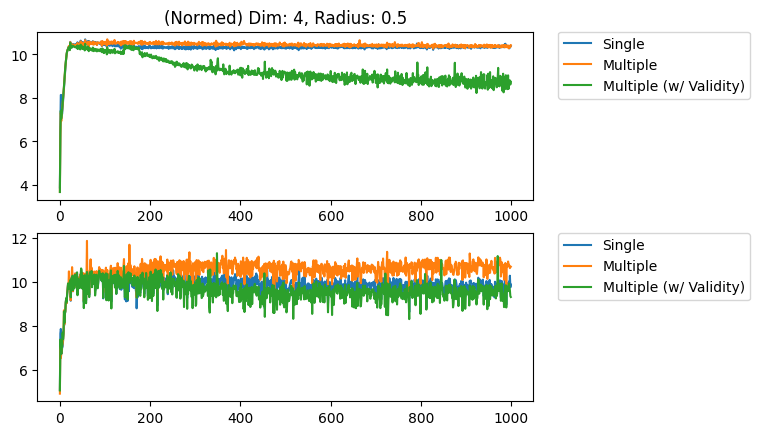

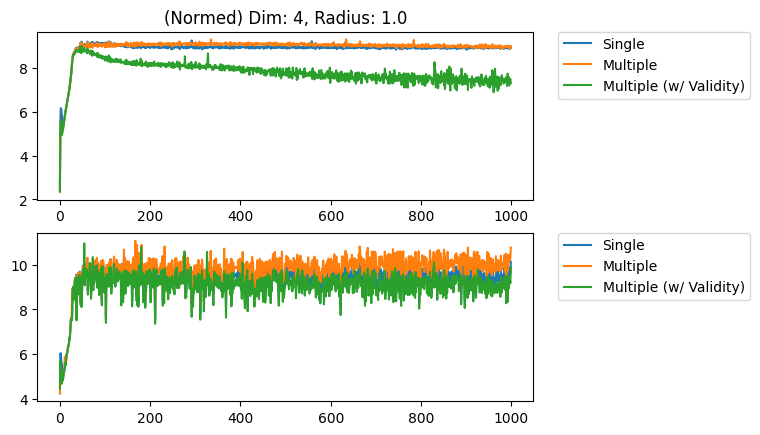

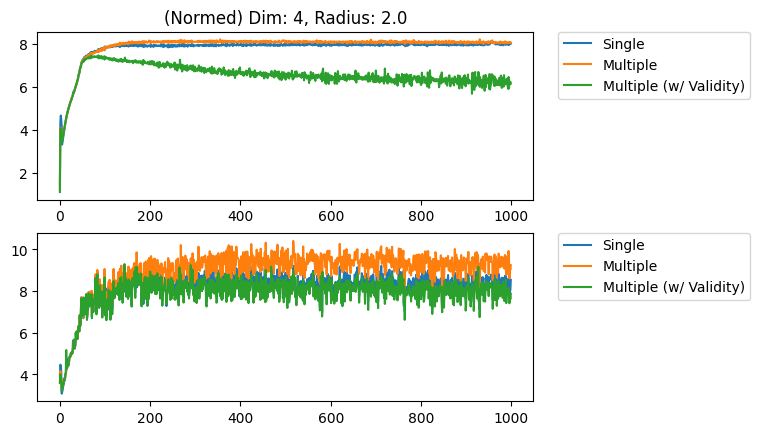

In [10]:
# compare the losses between modes at each dimension/radius so that way we can directly compare performance between each intrinsic method
for dim, radius in itertools.product(DIMS, RADII):
    title = f"(Normed) Dim: {dim}, Radius: {radius}"

    training_data_for_dim_radius = list(
        filter(lambda data: data["n"] == dim and data["radius"] == radius, training_data)
    )
    cfg_data_for_mode = [
        list(filter(lambda data: data["mode"].value == mode_idx, training_data_for_dim_radius)) for mode_idx in
        range(len(MODES) - 1)
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for mode, cfg_data in zip(MODES, cfg_data_for_mode):
        label = mode

        avg_cfg_train_loss = sum(data["norm_train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["norm_valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)



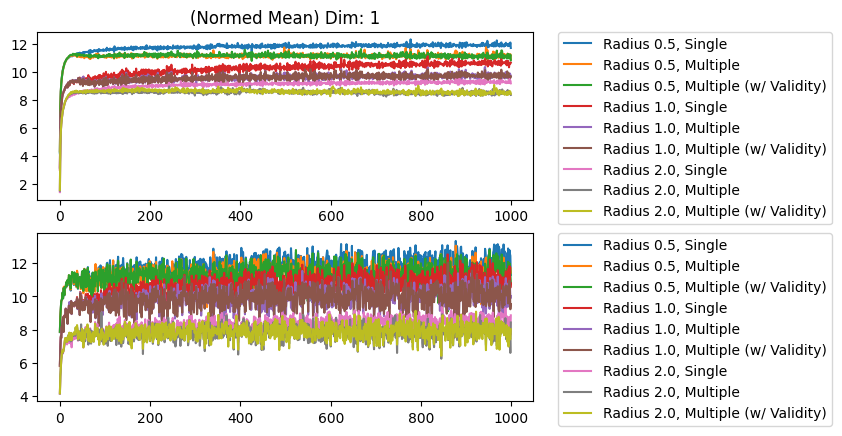

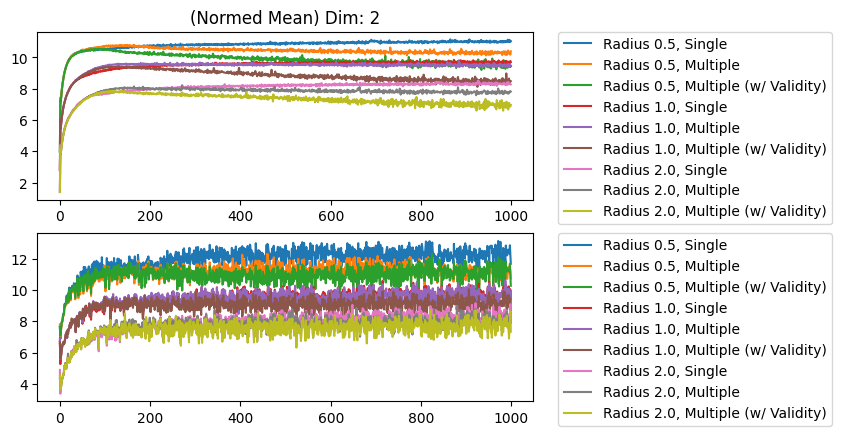

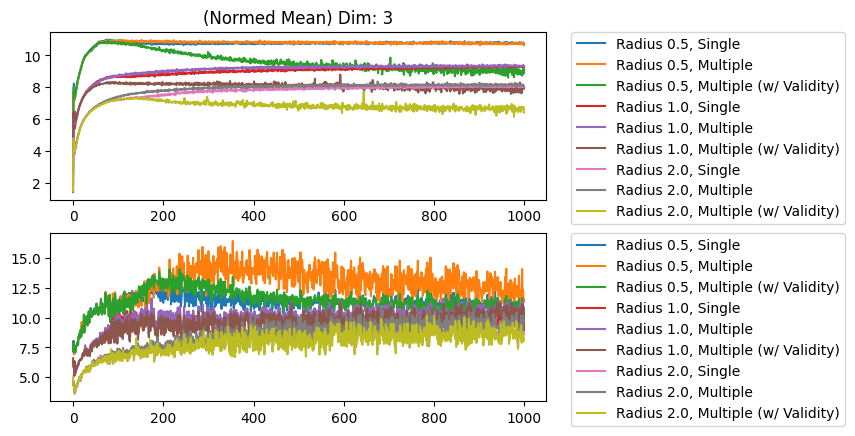

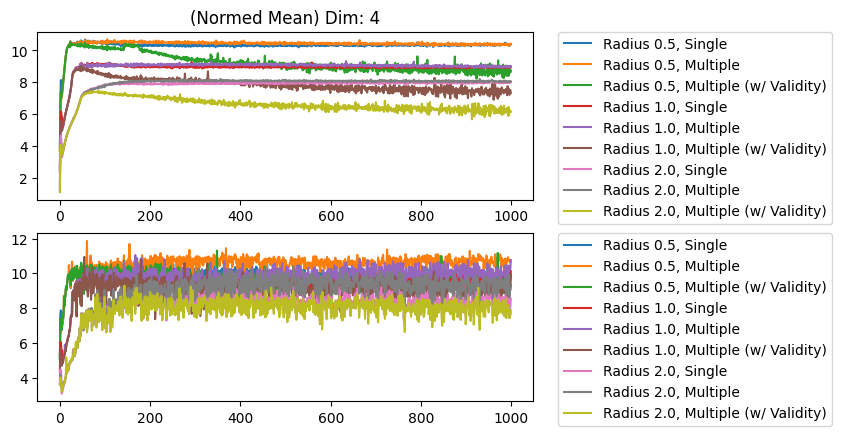

In [11]:
# for purposes of comparison then lets combine all radii results into single graphs so we can make comparisons on training performance
for dim in DIMS:
    title = f"(Normed Mean) Dim: {dim}"

    training_data_for_dim = list(
        filter(lambda data: data["n"] == dim, training_data)
    )
    mode_radius_cfgs = list(itertools.product(range(len(MODES) - 1), RADII))
    mode_radius_cfgs.sort(key=lambda x: x[1])
    cfg_data_for_mode_radius = [
        list(filter(lambda data: data["mode"].value == mode_idx and data["radius"] == radius,
                    training_data_for_dim)) for mode_idx, radius in mode_radius_cfgs
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for (mode_idx, radius), cfg_data in zip(mode_radius_cfgs, cfg_data_for_mode_radius):
        label = f"Radius {radius}, {MODES[mode_idx]}"

        avg_cfg_train_loss = sum(data["norm_train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["norm_valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


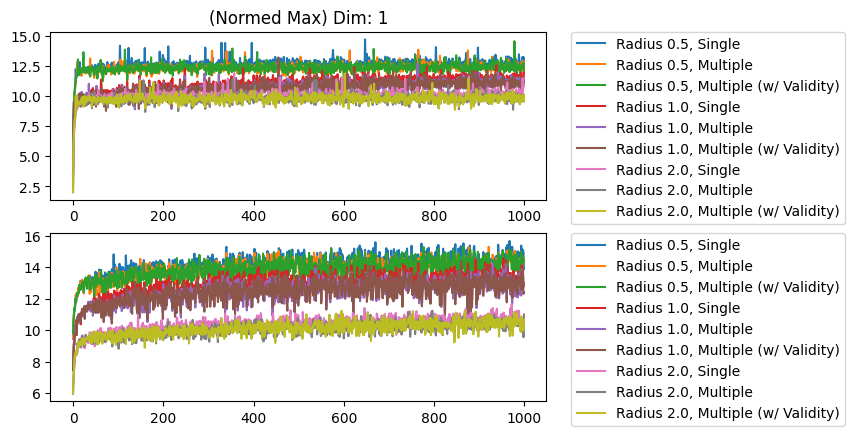

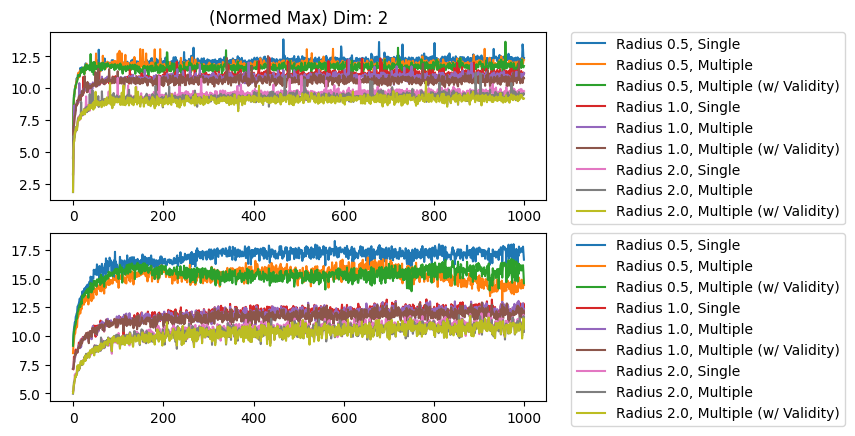

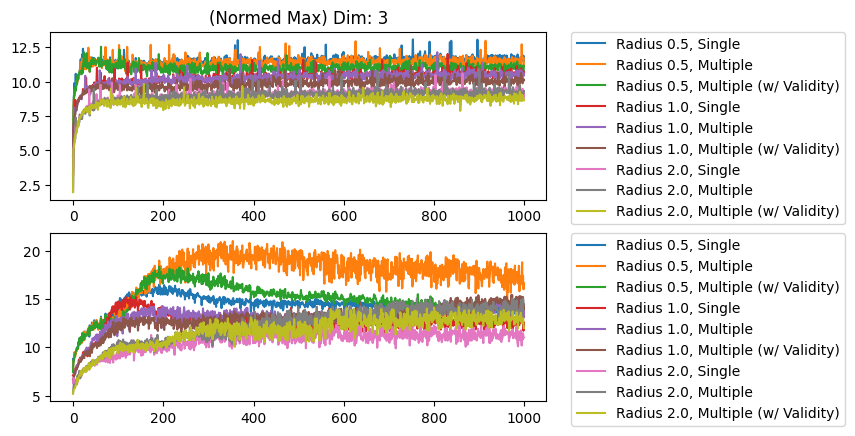

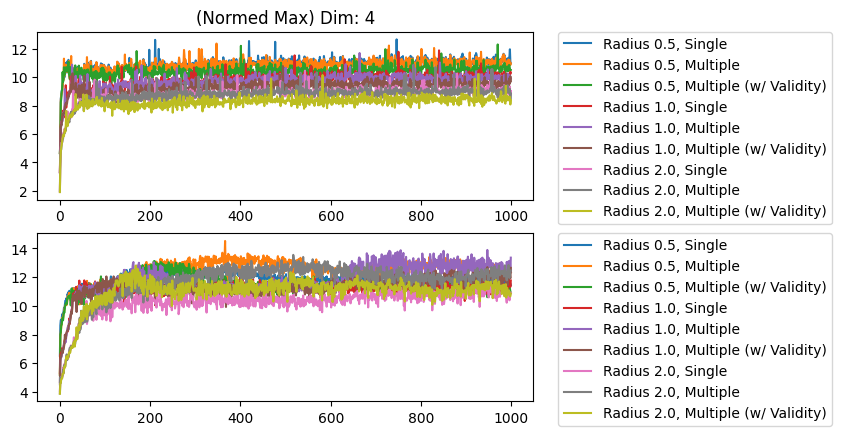

In [12]:
# complete the previous assessment with the worst case batch loss
for dim in DIMS:
    title = f"(Normed Max) Dim: {dim}"

    training_data_for_dim = list(
        filter(lambda data: data["n"] == dim, training_data)
    )
    mode_radius_cfgs = list(itertools.product(range(len(MODES) - 1), RADII))
    mode_radius_cfgs.sort(key=lambda x: x[1])
    cfg_data_for_mode_radius = [
        list(filter(lambda data: data["mode"].value == mode_idx and data["radius"] == radius,
                    training_data_for_dim)) for mode_idx, radius in mode_radius_cfgs
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for (mode_idx, radius), cfg_data in zip(mode_radius_cfgs, cfg_data_for_mode_radius):
        label = f"Radius {radius}, {MODES[mode_idx]}"

        avg_cfg_train_loss = sum(data["norm_train_max_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["norm_valid_max_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


In [28]:
# compute statistics for the final iterations (once fully trailed)
avg_final_mean_train_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
std_final_mean_train_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
avg_final_mean_valid_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
std_final_mean_valid_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))

avg_final_max_train_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
std_final_max_train_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
avg_final_max_valid_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))
std_final_max_valid_losses = np.zeros((len(RADII), len(MODES) - 1, len(DIMS)))

EPOCHS_TO_AVG = 100

for data in training_data:
    # skip extrinsic data as we're still using the relative comparison
    if data["mode"].value == DynamicsDatasetMode.EXTRINSIC_COORD.value:
        continue

    radius_idx = RADII.index(data["radius"])
    mode_idx = data["mode"].value
    dim_idx = DIMS.index(data["n"])

    mean_final_train_rel_losses = data["norm_train_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]
    mean_final_valid_rel_losses = data["norm_valid_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]

    max_final_train_rel_losses = data["norm_train_max_batch_loss_hist"][-EPOCHS_TO_AVG:]
    max_final_valid_rel_losses = data["norm_valid_max_batch_loss_hist"][-EPOCHS_TO_AVG:]

    # takes average
    avg_final_mean_train_losses[radius_idx, mode_idx, dim_idx] = np.mean(mean_final_train_rel_losses)
    std_final_mean_train_losses[radius_idx, mode_idx, dim_idx] = np.std(mean_final_train_rel_losses)

    avg_final_mean_valid_losses[radius_idx, mode_idx, dim_idx] = np.mean(mean_final_valid_rel_losses)
    std_final_mean_valid_losses[radius_idx, mode_idx, dim_idx] = np.std(mean_final_valid_rel_losses)

    avg_final_max_train_losses[radius_idx, mode_idx, dim_idx] = np.mean(max_final_train_rel_losses)
    std_final_max_train_losses[radius_idx, mode_idx, dim_idx] = np.std(max_final_train_rel_losses)

    avg_final_max_valid_losses[radius_idx, mode_idx, dim_idx] = np.mean(max_final_valid_rel_losses)
    std_final_max_valid_losses[radius_idx, mode_idx, dim_idx] = np.std(max_final_valid_rel_losses)

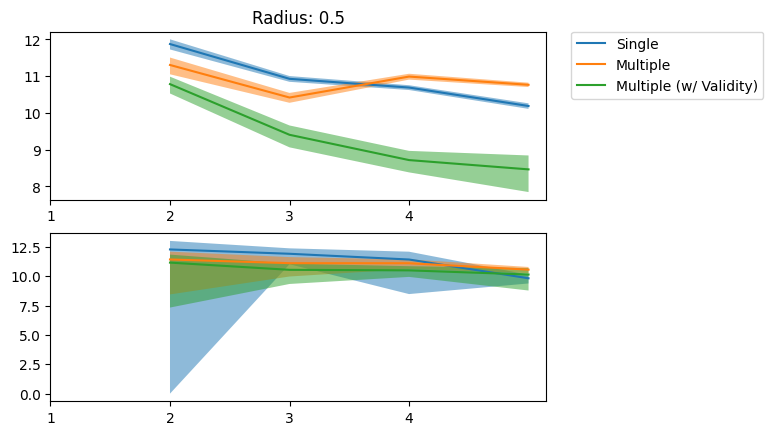

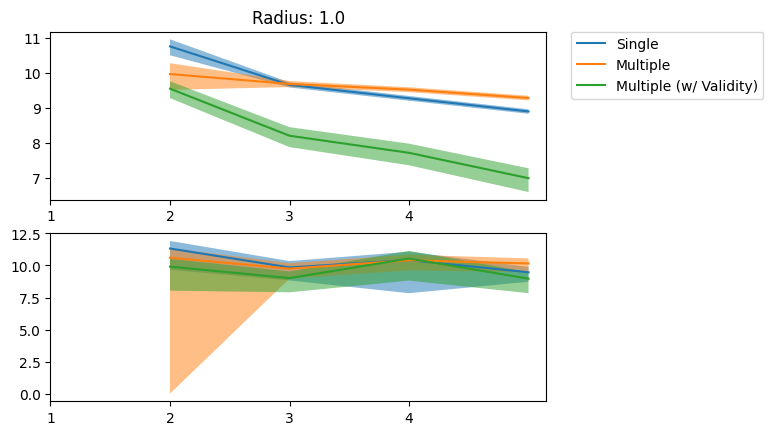

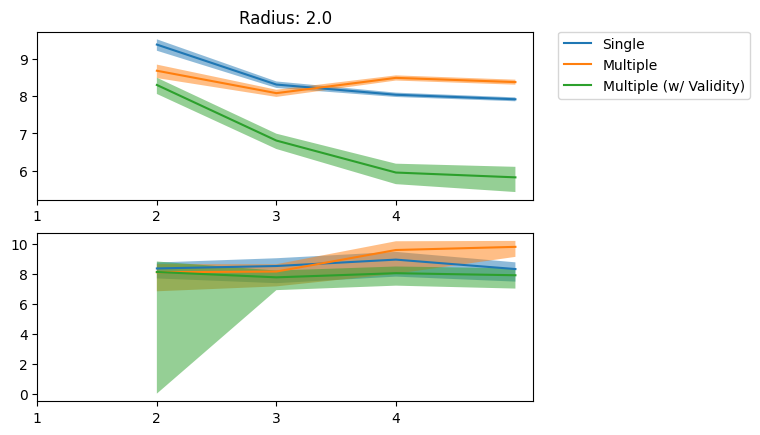

In [40]:
for radius_idx in range(len(RADII)):
    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    title = f"Radius: {RADII[radius_idx]}"

    train_ax.set_title(title)
    for mode_idx in range(len(MODES) - 1):
        label = MODES[mode_idx]

        mode_mean_train_data = avg_final_mean_train_losses[radius_idx, mode_idx, :]
        mode_std_train_data = std_final_mean_train_losses[radius_idx, mode_idx, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[radius_idx, mode_idx, :]
        mode_std_valid_data = std_final_mean_valid_losses[radius_idx, mode_idx, :]

        train_ax.plot(DIMS, np.log(mode_mean_train_data), label=label)
        train_ax.fill_between(DIMS,
                              np.log(np.maximum(mode_mean_train_data - mode_std_train_data,
                                                np.ones_like(mode_mean_train_data))),
                              np.log(mode_mean_train_data + mode_std_train_data), alpha=0.5)

        valid_ax.plot(DIMS, np.log(mode_mean_valid_data), label=label)
        valid_ax.fill_between(DIMS,
                              np.log(np.maximum(mode_mean_valid_data - mode_std_valid_data,
                                                np.ones_like(mode_mean_valid_data))),
                              np.log(mode_mean_valid_data + mode_std_valid_data), alpha=0.5)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    tick_idxs = list(range(len(DIMS)))
    train_ax.set_xticks(tick_idxs, DIMS)
    # valid_ax.legend()
    valid_ax.set_xticks(tick_idxs, DIMS)
    pass

In [ ]:
# separate the training data by the various modes
# NOTE: when saving for some reason numpy placed the mode into an array so we need to call .item() to get the underlying enum value first
training_data_by_mode = [
    [data for data in training_data if data['mode'].item().value == mode] for mode in range(len(MODES))
]

print(len(training_data_by_mode[0]))

In [ ]:
# plot the losses for all training configurations and hyperparameters for the single chart mode with dimension 4 as an example of the trials conducted
# NOTE: due to length limitations in the report we will not be able to present all of these results so this will serve as the example and will show that the averaging methodology is valid

single_chart_dim_4_data = [
    data for data in training_data_by_mode[0] if data["n"] == 4
]
len(single_chart_dim_4_data)

fig, (ax_train, ax_valid) = plt.subplots(1, 2)

labelled_single_chart_dim_4_data = []
for data in single_chart_dim_4_data:
    num_hidden_layers = data["num_hidden_layers"]
    num_nodes = data["num_nodes_in_hidden_layer"]
    radius = data['radius']
    lr = data['lr']
    batch_size = data['batch_size']

    cfg = get_cfg(num_hidden_layers, num_nodes)
    cfg_label = CONFIGS[cfg]['label']

    label = f"{CONFIGS[cfg]['label']}, Radius {data['radius']}"  # , LR {lr}, Batch Size {batch_size}"

    ax_train.plot(cfg["train_batch_"])

    print(label)

    pass